In [1]:
import os
from pathlib import Path
import gc

import numpy as np
import matplotlib.pyplot as plt

import keras

import torch
from torch.utils.data import DataLoader, TensorDataset 

from skyrmion_dataset import SKYRMION

os.environ["KERAS_BACKEND"] = "torch"

import tensorflow as tf

2025-04-23 13:49:36.000723: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 13:49:36.001877: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-23 13:49:36.007406: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-23 13:49:36.020202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745408976.042681   65182 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745408976.04

In [2]:
from grad_cam import GradCAM

In [3]:
import numpy as np

In [4]:
dataset = np.load((Path("data") / "test" / "my_test_data").with_suffix(".npz"))

In [5]:
data = dataset["data"]
labels = dataset["labels"]

In [6]:
model = keras.models.load_model((Path("saved_models") / "sub" / "new_augment" / "model5-2025-04-07_002238-aug=c,dec=cosine,fag=F,fil=32,hea=sigmoid,los=KLD,pad=valid,per=True,pha=N+c+c").with_suffix(".keras"), compile=False)

W0000 00:00:1745408985.977498   65182 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
Nsamp = np.random.choice(data.shape[0], 16)
batch_images = data[Nsamp]
batch_labels = labels[Nsamp]

Instructions for updating:
Use tf.identity with explicit device placement instead.


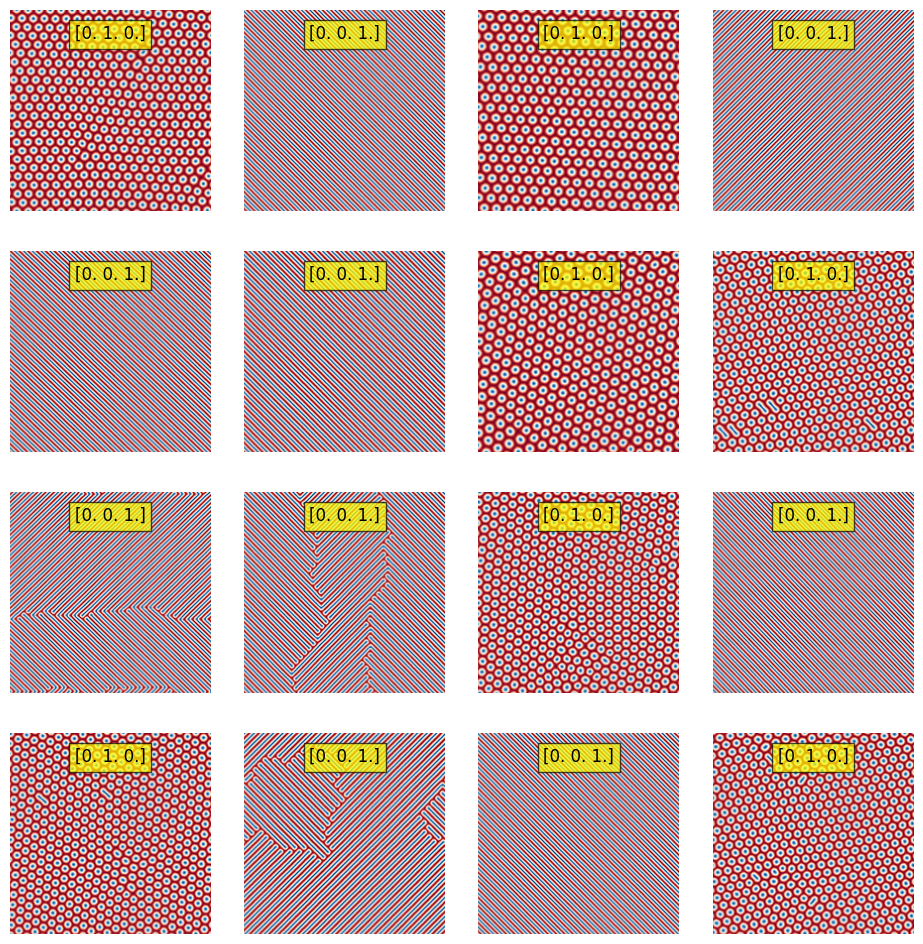

In [8]:
SKYRMION.visualize_images(batch_images, labels=model(batch_images).cpu().numpy(), row_size=4)

In [9]:
for layer in reversed(model.layers):
            if isinstance(layer, (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
                target_layer = layer
                break
            elif isinstance(layer, keras.models.Sequential):
                if layer.layers and isinstance(layer.layers[-1], (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
                    target_layer = layer.layers[-1]
                    break

In [10]:
target_layer.name

'conv2d_2'

In [11]:
imgs = torch.Tensor(batch_images).unsqueeze(-1)
lbls = torch.Tensor(batch_labels)
imgs.shape

torch.Size([16, 200, 200, 1])

In [12]:
gradcam = GradCAM(model)  # Use your final conv layer name
heatmaps = gradcam(imgs, lbls)  # shape: (B, H, W)

/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=torch.Size([16, 200, 200, 1]))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 200, 200, 1))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=torch.Size([16, 200, 200, 1]))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functiona

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m140211156848736\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tensor([[[[0.1668],\n          [0.0239],\n          [0.0943],\n          ...,\n          [0.7789],\n          [0.5877],\n          [0.3551]],\n\n         [[0.1569],\n          [0.0228],\n          [0.1110],\n          ...,\n          [0.7839],\n          [0.5633],\n          [0.3449]],\n\n         [[0.1225],\n          [0.0168],\n          [0.0847],\n          ...,\n          [0.6641],\n          [0.4863],\n          [0.2934]],\n\n         ...,\n\n         [[0.0476],\n          [0.0370],\n          [0.0419],\n          ...,\n          [0.2221],\n          [0.1637],\n          [0.0844]],\n\n         [[0.0821],\n          [0.0107],\n          [0.0761],\n          ...,\n          [0.4334],\n          [0.3308],\n          [0.1854]],\n\n         [[0.1406],\n          [0.0269],\n          [0.0974],\n          ...,\n          [0.6379],\n    

In [12]:
# Convert PyTorch tensors to TF tensors with proper dtype and shape
images_tf = tf.convert_to_tensor(batch_images, dtype=tf.float32)
labels_tf = tf.convert_to_tensor(batch_labels, dtype=tf.float32)

# GradCAM instance
gradcam = GradCAM(model)  # Use your final conv layer name
heatmaps = gradcam(images_tf, labels_tf)  # shape: (B, H, W)

/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 200, 200))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 200, 200))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 200, 200, 1))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The str

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m140007345066032\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(16, 200, 200), dtype=float32)\n  • training=None\n  • mask=None'

In [ ]:
gradcam = GradCAM(model)
# cams = gradcam.generate(batch_images, class_idx=batch_labels)
show_gradcam(gradcam, batch_images, batch_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 200, 200, 1))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 200, 200, 1))
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 200, 200, 1))']
  warnings.warn(msg)
/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWar

/home/rothals/dev/school/diploma_thesis/dev/venv/lib64/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 200, 200, 1))
  warnings.warn(msg)


KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m140246804477648\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 200, 200, 1), dtype=float32)\n  • training=None\n  • mask=None'

<Figure size 4800x300 with 0 Axes>